# EDA

In [60]:
# Import libraries
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi
from pathlib import Path

from PIL import Image

import matplotlib.pyplot as plt

import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import numpy as np

import hashlib

In [61]:
# config variables
config_dir = os.environ.get('KAGGLE_CONFIG_DIR', '.')
PROJECT_ROOT = Path(config_dir).resolve()

DATASET_NAME = "anujms/car-damage-detection"
DATA_DIR = PROJECT_ROOT / "data"
KAGGLE_KEY_PATH = PROJECT_ROOT / "kaggle.json"

EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}


print(f"Working directory: {PROJECT_ROOT}")
print(f"Looking for Kaggle key in: {KAGGLE_KEY_PATH}")

Working directory: /workspace
Looking for Kaggle key in: /workspace/kaggle.json


## 1. - Donwload files

In [62]:
def empty_folder_wo_dsstore(path: Path) -> bool:
    """
    Returns True if the folder is empty or only contains .DS_Store (mac users).
    """
    try:
        visible_elements = [
            item for item in path.iterdir()
            if item.name != ".DS_Store"
        ]
        return len(visible_elements) == 0
    except FileNotFoundError:
        print(f"The folder {path} does not exist.")
        return True
    except PermissionError:
        print(f"You do not have permission to access {path}.")
        return True


def download_and_extract():
    if not KAGGLE_KEY_PATH.exists():
        if Path("kaggle.json").exists():
             print("Found kaggle.json in the current folder, but KAGGLE_CONFIG_DIR points to another location.")
        else:
            raise FileNotFoundError(f"Not found 'kaggle.json' in {PROJECT_ROOT}. \n¡Ensure that the file is in the same folder as docker-compose.yml!")

    try:
        os.chmod(KAGGLE_KEY_PATH, 0o600)
    except Exception:
        print("Unable to change file permissions (normal in Docker on Windows), ignoring warning...")

    if DATA_DIR.exists() and empty_folder_wo_dsstore(DATA_DIR) is False:
        print("The dataset has already been downloaded to 'data/'.")
        return

    print("Starting download...")
    
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files(DATASET_NAME, path=DATA_DIR, unzip=False)
    
    print("Decompressing...")
    zip_path = list(DATA_DIR.glob("*.zip"))[0]
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(DATA_DIR)
        
    os.remove(zip_path)
    print(f"Done! Data in: {DATA_DIR}")


In [63]:
DATA_DIR.mkdir(parents=True, exist_ok=True)
download_and_extract()

Starting download...
Dataset URL: https://www.kaggle.com/datasets/anujms/car-damage-detection
Decompressing...
Done! Data in: /workspace/data


## 2. - Clean Data

In [64]:
def validate_images(folder_path):
    print(f"Checking folder: {folder_path}")
    corrupt_count = 0
    valid_count = 0
    
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in EXTENSIONS:
            try:
                with Image.open(filepath) as img:
                    img.verify() 
                valid_count += 1
            except (IOError, SyntaxError) as e:
                print(f"Corrupt image found:{filepath} -> By removing...")
                os.remove(filepath)
                corrupt_count += 1
    
    print(f"Finished {folder_path.name}: {valid_count} valid, {corrupt_count} eliminated.\n")



In [65]:
if not DATA_DIR.exists():
    print("Not found the 'data' folder...")
else:
    validate_images(DATA_DIR)

Checking folder: /workspace/data
Finished data: 2300 valid, 0 eliminated.



## 3. - EDA: Exploratory Data Analysis

In [66]:
def show_samples(folder, title):
    plt.figure(figsize=(12, 4))
    images = list(folder.glob("*"))[:5]
    for i, img_path in enumerate(images):
        plt.subplot(1, 5, i+1)
        img = mpimg.imread(str(img_path))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
    plt.show()

Damage route: /workspace/data/data1a/training/00-damage
Whole route: /workspace/data/data1a/training/01-whole
Damage: 920
Whole: 920


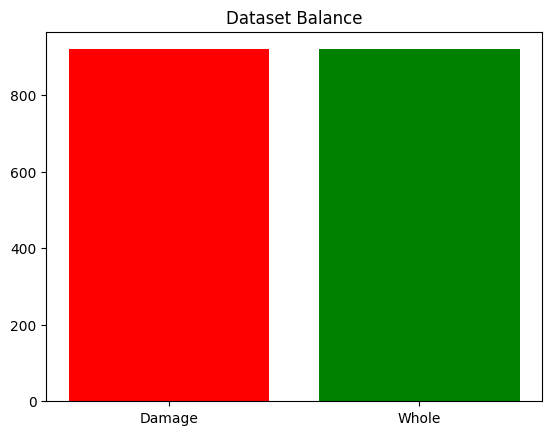

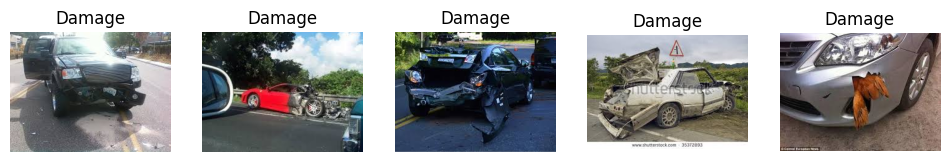

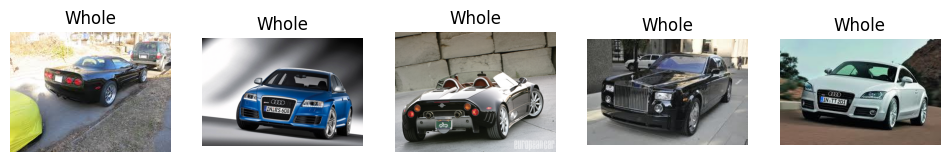

In [67]:
damage_dir = list(DATA_DIR.glob("**/00-damage"))[0]
whole_dir = list(DATA_DIR.glob("**/01-whole"))[0]

print(f"Damage route: {damage_dir}")
print(f"Whole route: {whole_dir}")

n_damage = len(list(damage_dir.glob("*")))
n_whole = len(list(whole_dir.glob("*")))

print(f"Damage: {n_damage}")
print(f"Whole: {n_whole}")

plt.bar(['Damage', 'Whole'], [n_damage, n_whole], color=['red', 'green'])
plt.title("Dataset Balance")
plt.show()

show_samples(damage_dir, "Damage")
show_samples(whole_dir, "Whole")

### 3.1 - Analysis of Dimensions and Aspect Ratio
CNNs require a fixed input (e.g. 224x224 pixels). If the original images are very elongated (panoramic) or very small (icons), resizing them will distort or pixelate them, causing key damage information to be lost.

In [68]:
def get_image_metadata(folder_path, label):
    data = []
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with Image.open(filepath) as img:
                width, height = img.size
                data.append({
                    "filename": filepath.name,
                    "width": width,
                    "height": height,
                    "aspect_ratio": width / height,
                    "label": label
                })
    return data

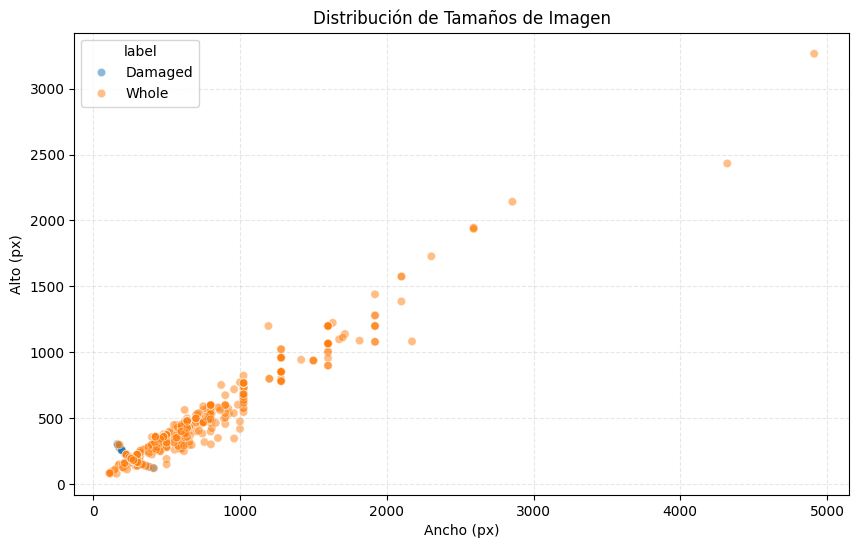

         width                                                               \
         count        mean         std    min    25%    50%     75%     max   
label                                                                         
Damaged  920.0  266.231522   26.699099  165.0  259.0  260.0  275.00   414.0   
Whole    920.0  628.844565  441.675540  112.0  300.0  580.0  776.25  4912.0   

        height              ...                aspect_ratio            \
         count        mean  ...    75%     max        count      mean   
label                       ...                                         
Damaged  920.0  191.189130  ...  194.0   306.0        920.0  1.422345   
Whole    920.0  432.904348  ...  492.0  3264.0        920.0  1.472238   

                                                                     
              std       min       25%       50%       75%       max  
label                                                                
Damaged  0.278639  0.539216 

In [69]:
meta_damage = get_image_metadata(damage_dir, "Damaged")
meta_whole = get_image_metadata(whole_dir, "Whole")

df = pd.DataFrame(meta_damage + meta_whole)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="width", y="height", hue="label", alpha=0.5)
plt.title("Distribución de Tamaños de Imagen")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(df.groupby('label')[['width', 'height', 'aspect_ratio']].describe())

As we can see in the distribution, most images have the same form factor (linear distribution) but come in many sizes (they are scattered), so we have to be careful when choosing the training size, because the smallest ones will become pixelated when resized (they are quite close to 0.0).

### 3.2 - Brightness and Intensity Analysis (Bias Detection)
We want to avoid bias in the brightness of the images, which would make the model unreliable. Imagine that all the photos of "Damaged Cars" were taken by experts on cloudy days or in dark garages, and those of "Undamaged Cars" are bright marketing photos. The model could learn that "Dark = Damaged".

In [70]:
def get_brightness(folder_path):
    brightness_vals = []
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with Image.open(filepath) as img:
                img_gray = img.convert('L')
                stat = np.array(img_gray).mean()
                brightness_vals.append(stat)
    return brightness_vals

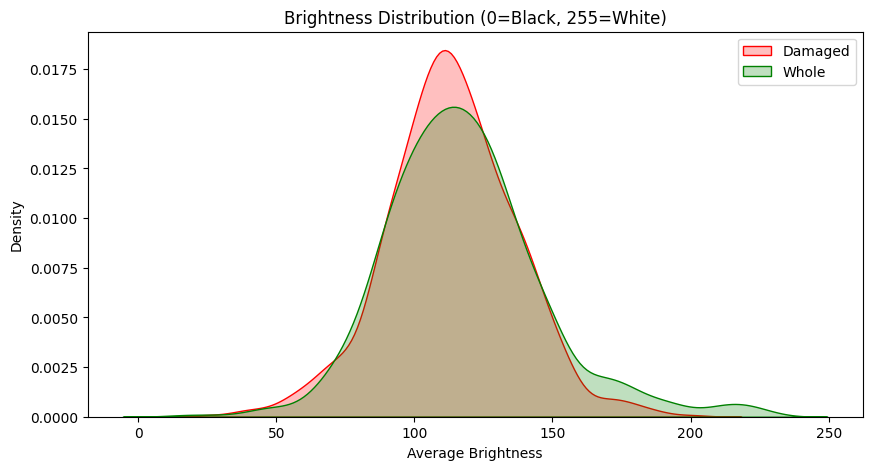

In [71]:
bright_damage = get_brightness(damage_dir)
bright_whole = get_brightness(whole_dir)

plt.figure(figsize=(10, 5))
sns.kdeplot(bright_damage, label='Damaged', fill=True, color='red')
sns.kdeplot(bright_whole, label='Whole', fill=True, color='green')
plt.title("Brightness Distribution (0=Black, 255=White)")
plt.xlabel("Average Brightness")
plt.legend()
plt.show()

Given that the two curves overlap, there is no bias.

### 3.3 - Duplicate Detection (Data Leakage)
We do not know the quality of the dataset, and it could contain duplicates. If the image coche_rojo_01.jpg is repeated three times, and unfortunately two appear in Train and one in Test, the model will cheat (it will memorise the photo). Exact duplicates must be removed.



In [72]:
def find_duplicates(folder_path):
    hashes = {}
    duplicates = []
    
    for filepath in folder_path.rglob("*"):
        if filepath.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            with open(filepath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
                
            if file_hash in hashes:
                duplicates.append((filepath, hashes[file_hash]))
            else:
                hashes[file_hash] = filepath
                
    return duplicates

In [73]:
dupes = find_duplicates(DATA_DIR)

print(f"{len(dupes)} exact duplicate images were found.")
if len(dupes) > 0:
    print("Example:", dupes[0])

13 exact duplicate images were found.
Example: (PosixPath('/workspace/data/data1a/training/00-damage/0012.JPEG'), PosixPath('/workspace/data/data1a/training/00-damage/0700.jpeg'))


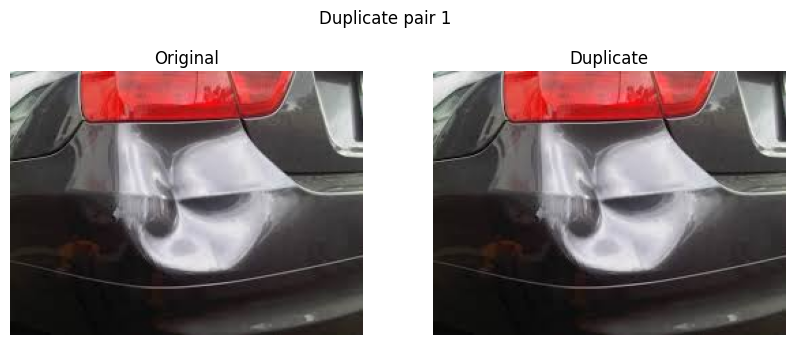

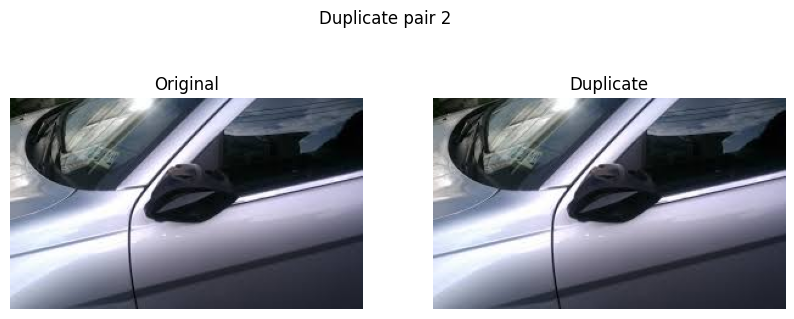

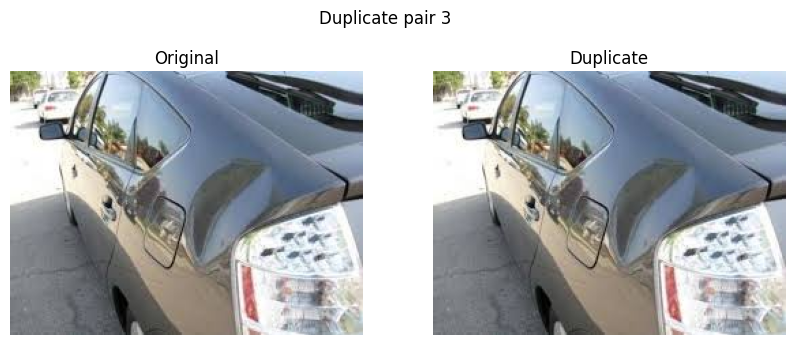

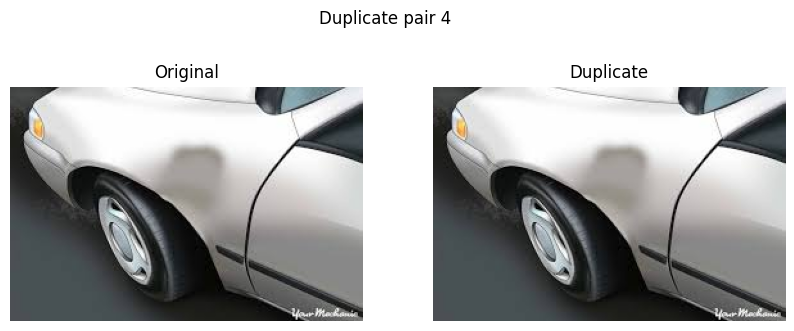

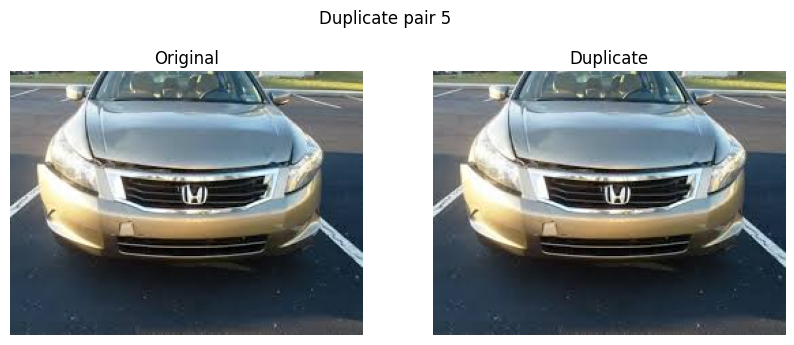

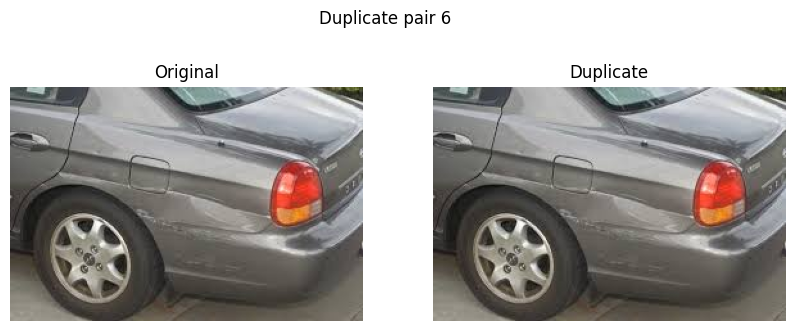

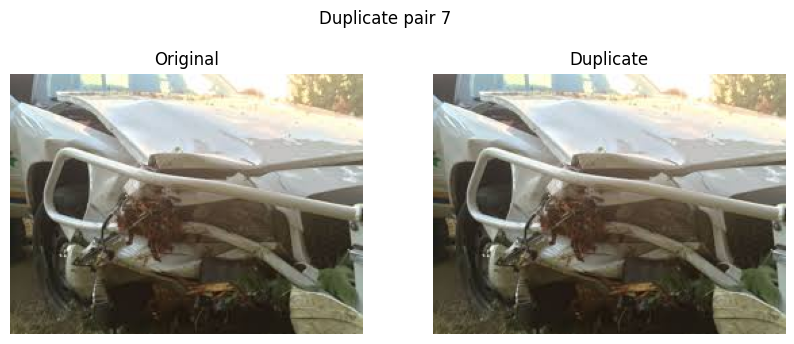

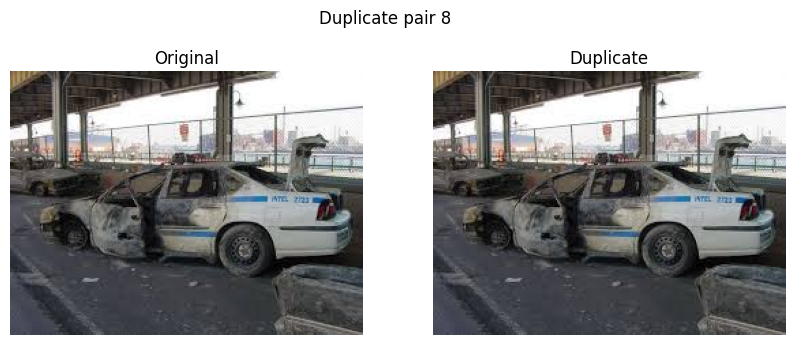

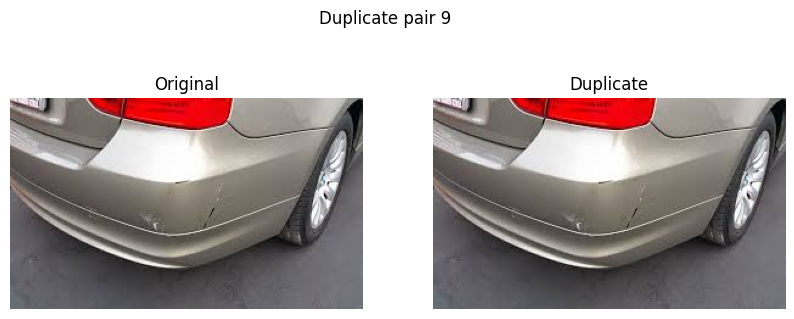

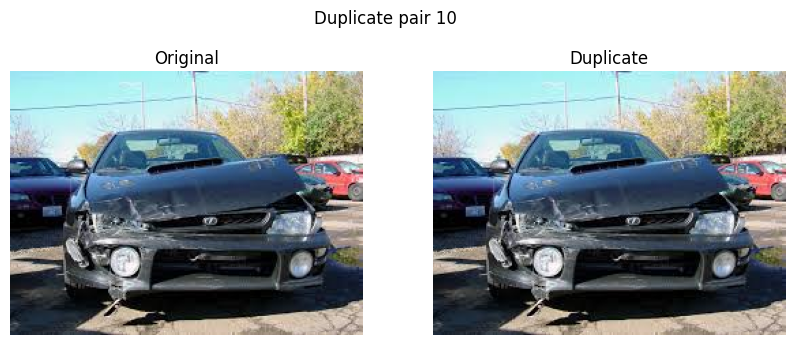

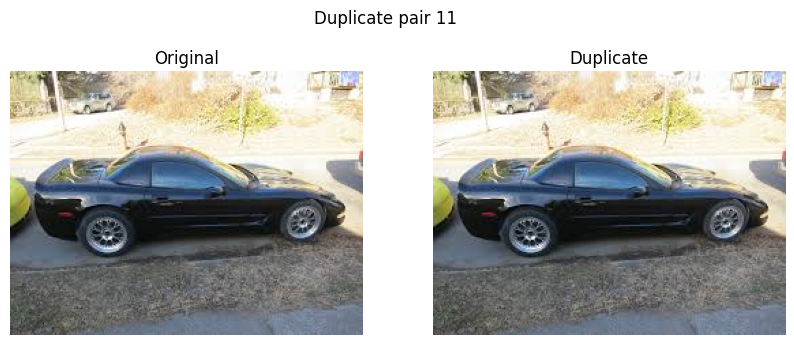

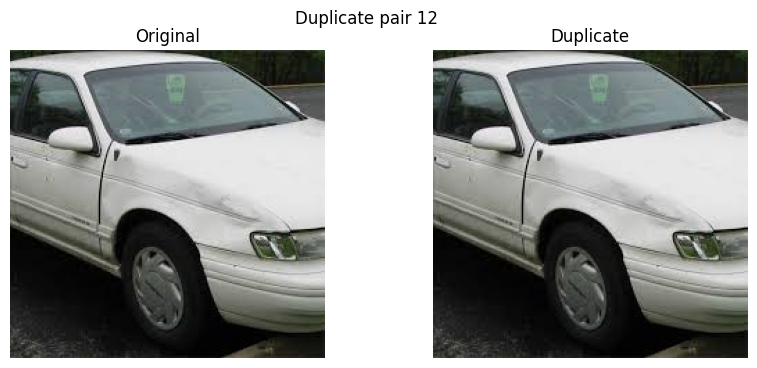

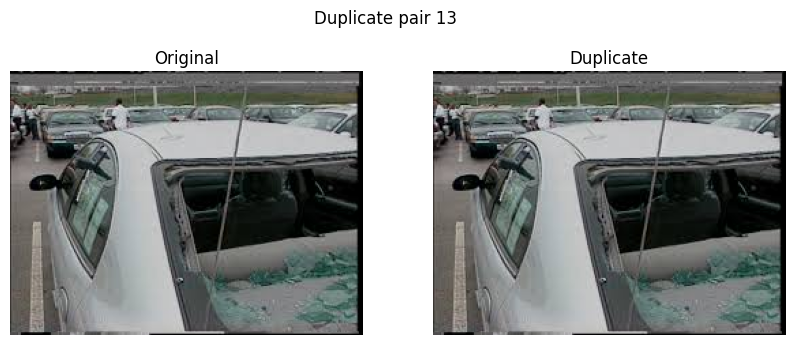

In [74]:
if len(dupes) == 0:
    print("No duplicates found.")
else:
    from matplotlib import pyplot as plt
    for idx, (dup, original) in enumerate(dupes):
        try:
            plt.figure(figsize=(10, 4))
            plt.suptitle(f"Duplicate pair {idx+1}")
            plt.subplot(1, 2, 1)
            plt.imshow(mpimg.imread(str(original)))
            plt.title("Original")
            plt.axis('off')
            plt.subplot(1, 2, 2)
            plt.imshow(mpimg.imread(str(dup)))
            plt.title("Duplicate")
            plt.axis('off')
            plt.show()
        except Exception as e:
            print(f"Error showing pair {idx+1}: {e}")

In [75]:
# Delete duplicates
for dup in dupes:
    os.remove(dup[0])

There were several duplicates that have been removed.

Summary of the EDA:

* Geometric Consistency: It is decided that the resize size will be: (Resize vs Padding).
* Bias Analysis (Brightness): A biased model is avoided.
* Data Integrity (Duplicates): Data leakage is avoided.